# Генеративная модель на основе гауссовых смесей

Гауссовы смеси — естественное математическое обобщение алгоритма `K-means`. По сути, подход ищет не просто какие-то кучки вокруг формирующихся центроидов, а некоторую смесь многомерных нормальных распределений (по сути — тоже кучки вокруг средних со своими дисперсиями). Так как такой подход оценивает плотности распределений, то он часто используется в задачах KDE (kernel density estimation). В том числе, он может быть применен к задаче генерации: если есть плотность распределения, то можно семплировать и получать новые объекты. Давайте посмотрим на простейший пример решения такой задачи.

Работать будем опять-таки с `MNIST`. Так как модель оказывается крайне тяжеловесной, будем использовать «простой» набор данных. Визуализируем элементы этого набора данных (для наглядности)

In [31]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

digits = load_digits()
digits.data.shape

(1797, 64)

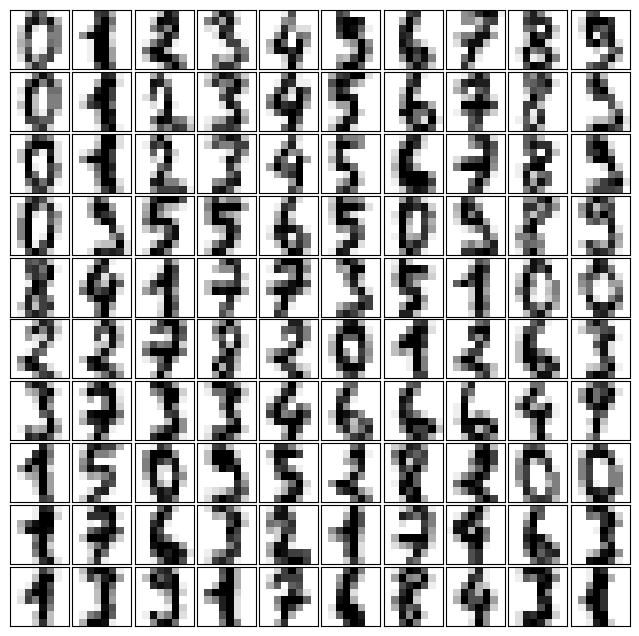

In [32]:
fig, ax = plt.subplots(10, 10, figsize=(8, 8), subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for i, axi in enumerate(ax.flat):
    im = axi.imshow(digits.data[i].reshape(8,8), cmap='binary')
    im.set_clim(0, 16)

Для того, чтобы обучение проходило быстрее имеет смысл снизить размерность пространства признаков. Произведите преобразования для всего набора данных помощи <code>PCA(n_components=0.99, svd_solver=='full')</code>.


In [33]:
from sklearn.decomposition import PCA
pca = PCA(n_components=0.99, svd_solver="full")

pca_data = pca.fit_transform(digits.data)

Введите число полученных ГК

In [34]:
pca_data.shape[1]

41

Обучим интересующую нас модель, подобрав гиперпараметр, отвечающий за число используемых компонент, минимизируя <a href="https://ru.wikipedia.org/wiki/Информационный_критерий_Акаике">информационный критерий Акаике</a>.

Для значений параметра <code>n_components</code> в диапазоне $[50,250)$ с шагом $10$ обучите модели <a href="https://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html"><code>GaussianMixture</code></a> с параметрами, указанными в вашем задании. При помоши метода <code>.aic()</code> вычислите значение критерия каждой модели.

Введите значение <code>n_components</code> модели с наименьшим значением критерия Акаике.




In [35]:
from sklearn.mixture import GaussianMixture


gm = GaussianMixture(n_components = 50, covariance_type = 'full', random_state = 77)
gm.fit(pca_data)

GaussianMixture(n_components=50, random_state=77)

In [ ]:
a = gm.aic(pca_data)
n = 50

for n_components in range(50, 249, 10):
    gm = GaussianMixture(n_components = n_components, covariance_type = 'full', random_state = 77)
    gm.fit(pca_data)

    if gm.aic(pca_data) < a:
        a = gm.aic(pca_data)
        n = n_components
n

190

Обучите финальную модель на подобранном гиперпараметре. Проверьте, что обучение сошлось (поле <code>.converged_</code> модели).

In [37]:
gm = GaussianMixture(n_components = n, covariance_type = 'full', random_state = 77)
gm.fit(pca_data)

GaussianMixture(n_components=190, random_state=77)

In [45]:
gm.converged_

True

При помощи метода <code>.sample()</code> сгенерируйте $100$ новых объектов.

Введите выборочное среднее коориднаты с индексом $0$ сгенерированных объектов.

In [38]:
sample = gm.sample(100)
f"{sample[0][:, 0].mean():.3f}"

'1.308'

При помоши метода <code>.inverse_transform()</code> класса <code>PCA</code> верните сгенерированные объекты в пространство исходных признаков.

In [56]:
inverse_sample = pca.inverse_transform(sample[0])
inverse_sample.shape

(100, 64)

Визуализируйте полученные результаты. Введите номер изображения, соответствующего сгенерированному объекту с индексом $5$ (индексация начинается с нуля)

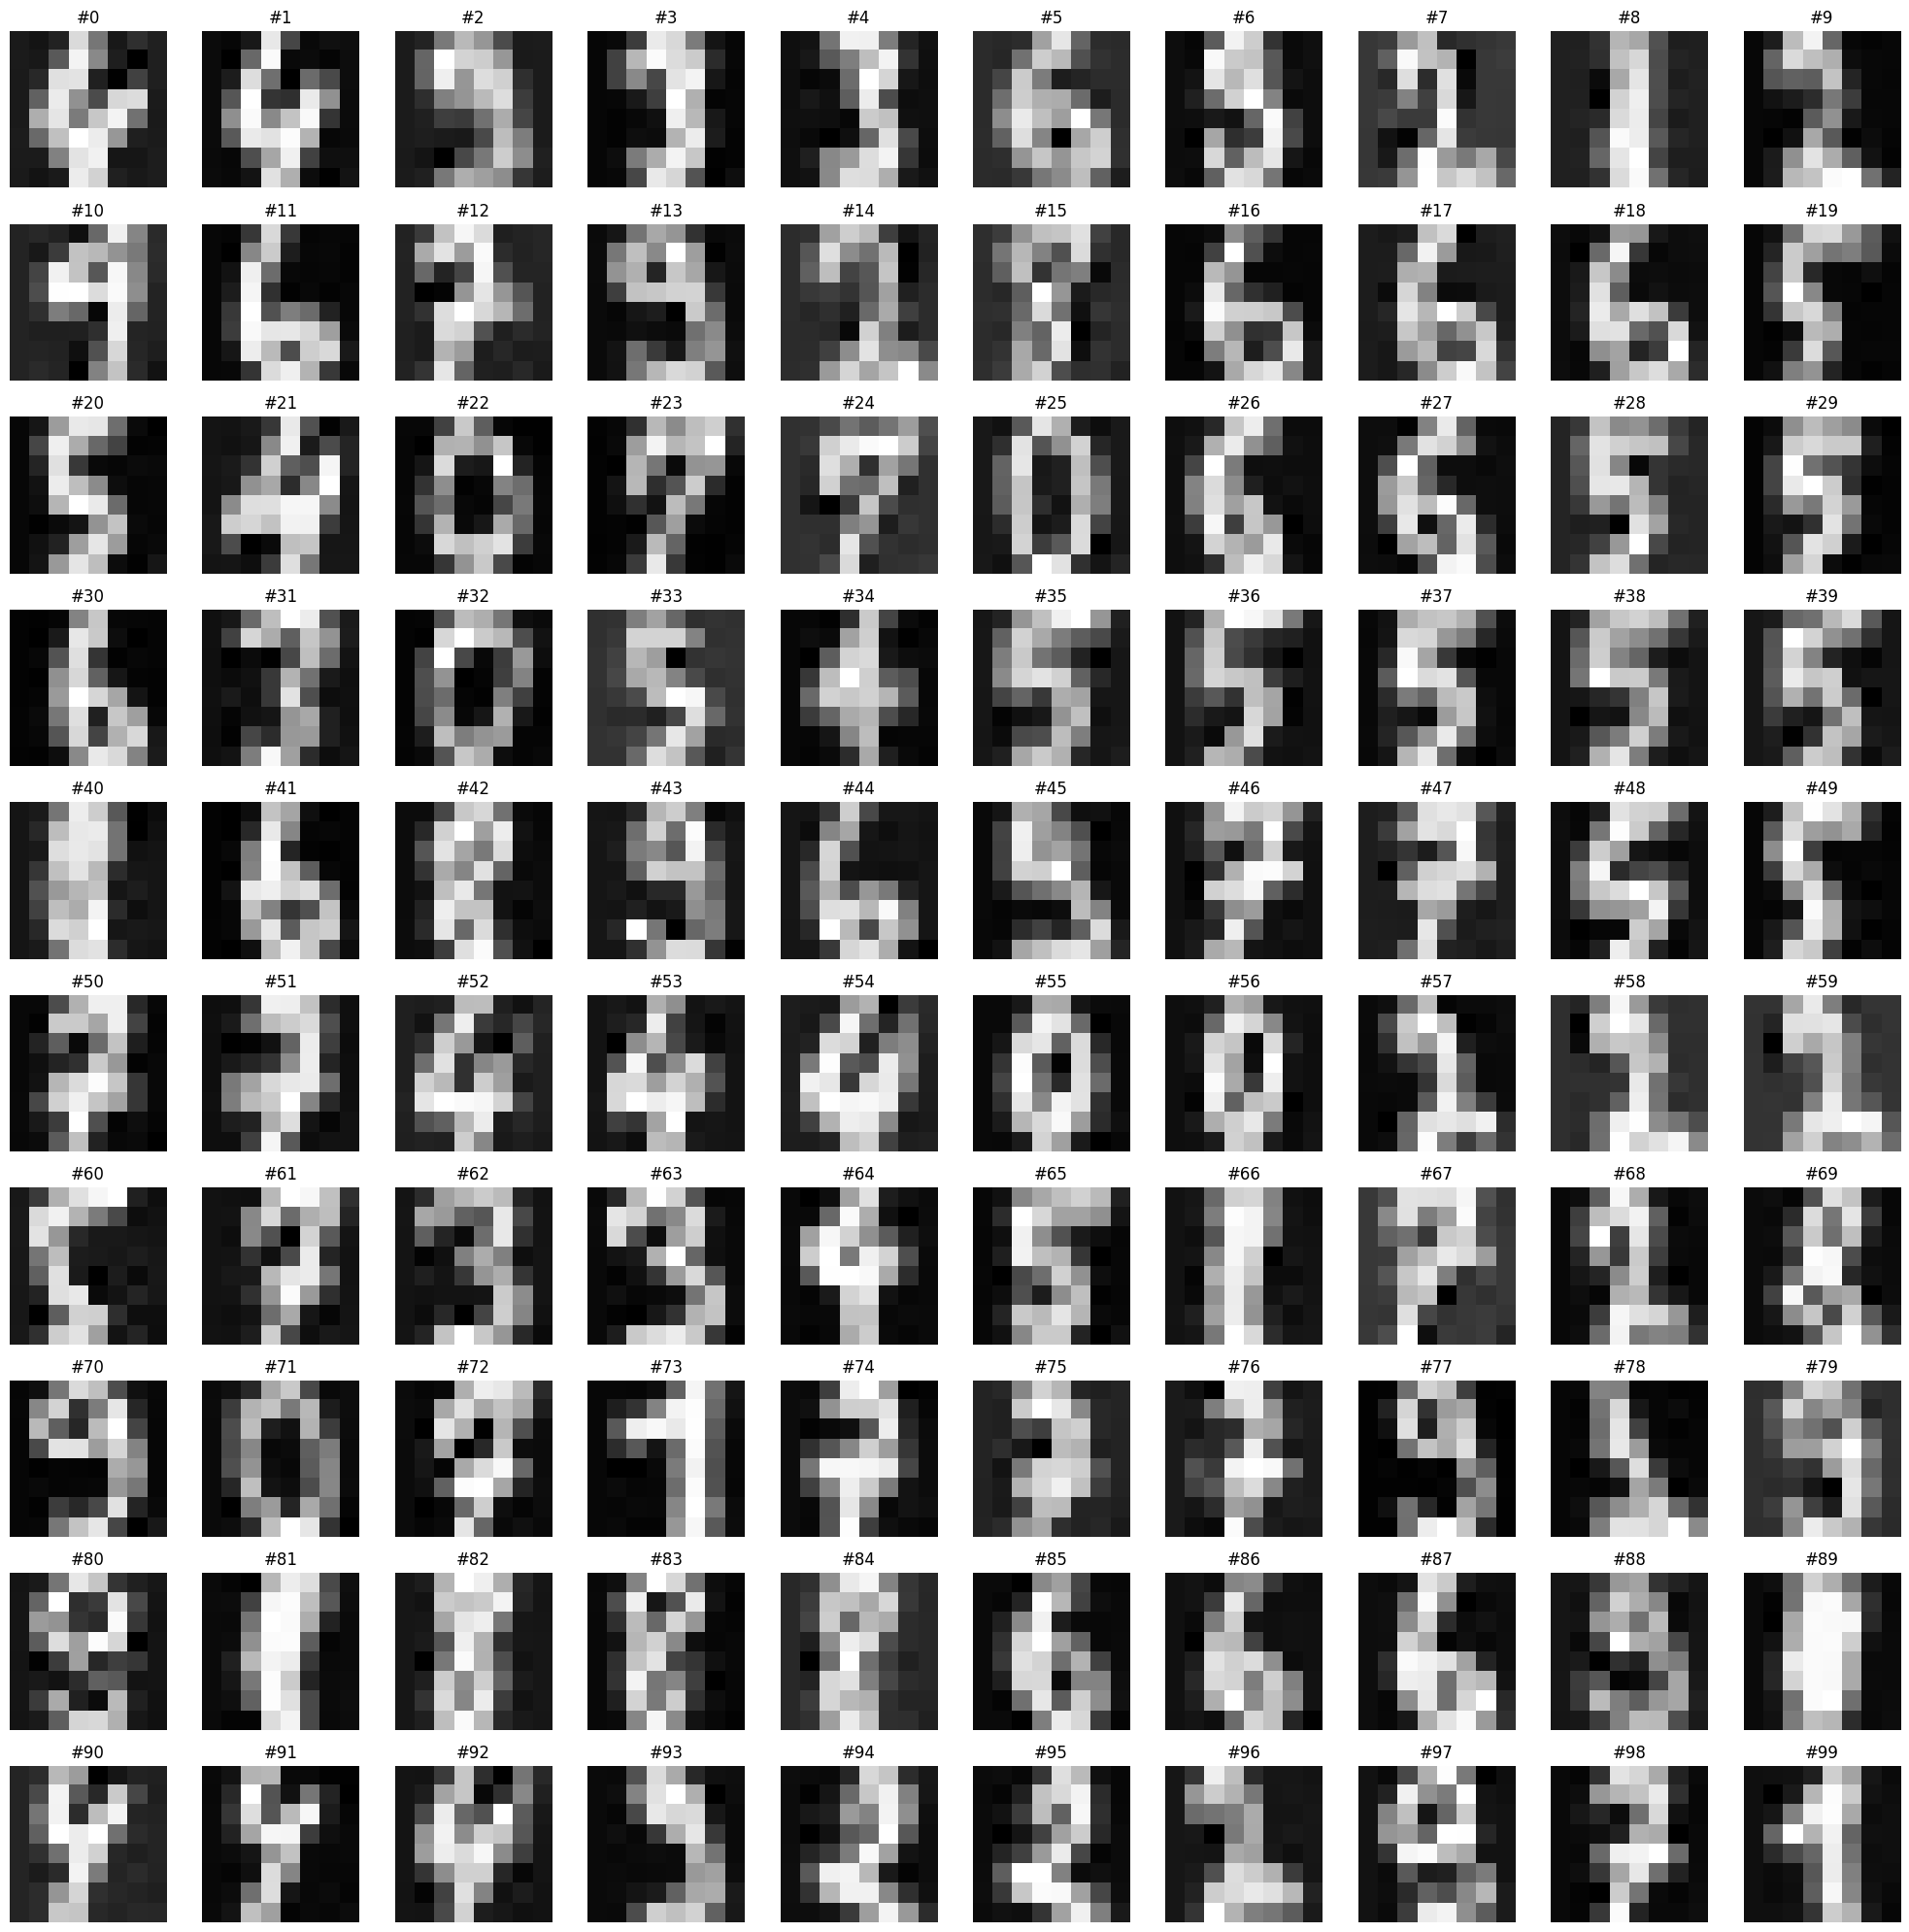

In [ ]:
n_samples = inverse_sample.shape[0]

n_cols = 10
n_rows = 10

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2, n_rows * 2))
axes = axes.flatten()

for i in range(n_samples):
    axes[i].imshow(inverse_sample[i].reshape(8, 8), cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f'#{i}')

for i in range(n_samples, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

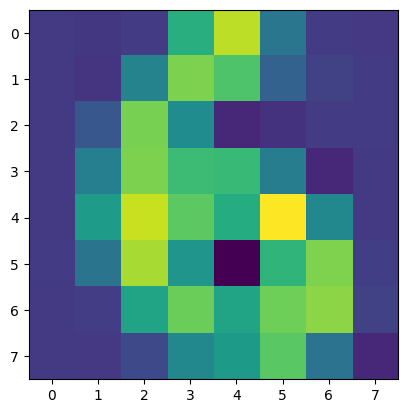

In [54]:
plt.imshow(inverse_sample[5].reshape(8, 8))

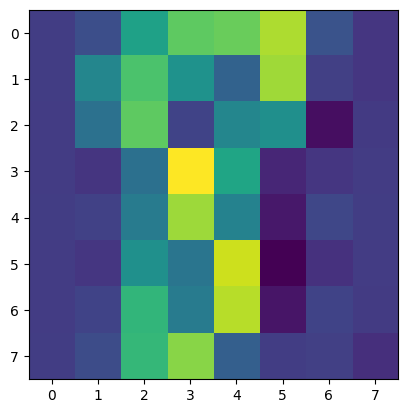

In [61]:
plt.imshow(inverse_sample[15].reshape(8, 8))